# Extended Data Figure 1

Sam Gould, Kexin Dong

Cleaned: May 1, 2026

Last Updated: May 1, 2026

Summary description & analysis of MBESv2 library.

In [2]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import scipy.stats
from sklearn.decomposition import PCA
from adjustText import adjust_text
from matplotlib_venn import venn2, venn3
from upsetplot import UpSet, from_indicators
import warnings
import os
warnings.filterwarnings('ignore')

# ── Global style (matching published figures) ─────────────────────────────
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['text.usetex']  = False
plt.rcParams['font.family']     = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']

blues   = sns.color_palette('Blues').as_hex()
greens  = sns.color_palette('Greens').as_hex()
reds    = sns.color_palette('Reds').as_hex()
yellows = sns.color_palette('Oranges').as_hex()
purples = sns.color_palette('Purples').as_hex()

greys = sns.color_palette('Greys').as_hex()
teals = sns.color_palette('BuPu').as_hex()
pinks = sns.color_palette('RdPu').as_hex()
browns = sns.color_palette('YlOrBr').as_hex()
BASE = '/Users/kexindong/Documents/GitHub/B-ALL-in-vivo-base-editing/'

In [5]:
MBES = pd.read_csv('MBESv2_CORRECTED.csv')
MBES = MBES[MBES['Pool']!='F3-R3']
MBES_targ = MBES[MBES['classification'] == 'targeting guide']

## 1a

Histogram of the "flank size," the number of homologous amino acids between the human and mouse protein on either side of the target amino acid being mutated, for missense and nonsense mutations in the MBESv2 library.

In [ ]:
#include a histogram of the flank sizes as well
MBES = pd.read_csv('MBESv2_CORRECTED.csv')

input_data = pd.read_csv('source_data/msk_BE_pts_over_2_v2.csv')
input_data2 = pd.read_csv('source_data/input_MSK_over_2.csv')

muts_aacr = pd.read_csv('/Users/samgould/Desktop/FSR Lab/reference files/AACR_genie/data_mutations_extended.txt', sep='\t')
msk_aacr = muts_aacr[(muts_aacr['Center']=='MSK') & (muts_aacr['Variant_Type']=='SNP')]


In [ ]:
df_mutation = pd.read_csv('/Users/samgould/Desktop/AACR_v13.1/data_mutations_extended.txt', header=0, sep='\t', comment="#", na_values = 'Not Applicable')

# only keep MSK data
df_mutation = df_mutation.iloc[:,[0, 37,2, 5,6,9,10,11,13,16]].reset_index(drop=True)
df_mutation = df_mutation[df_mutation['Center']=='MSK'].reset_index(drop=True)
df_mutation = df_mutation[df_mutation['Variant_Type'] == 'SNP'].reset_index(drop=True)
df_mutation = df_mutation.dropna(subset='HGVSc').reset_index(drop=True)
df_mutation['HGVSc'] = [x.split(':')[0] for x in df_mutation['HGVSc']]
df_mutation = df_mutation.drop_duplicates().reset_index(drop=True)

#and count tumor samples for a given mutation (by HGVSc)
df_mutation_count = df_mutation.groupby([df_mutation.columns.tolist()[x] for x in [0,1,3,4,5,6,7,8]], as_index = False).size()
df_mutation_count_sorted = df_mutation_count.sort_values(by = 'size')
df_mutation_count_sorted.columns =['gene_name_h', 'tx_id_h','start_h','end_h','class_h','type_h','ref_seq_h','alt_seq_h','count']

In [ ]:
mutations_over_2 = df_mutation_count_sorted[df_mutation_count_sorted['count']>2].reset_index(drop=True)

alteration = []
for i, val in mutations_over_2.iterrows():
    ref = val['ref_seq_h']
    alt = val['alt_seq_h']
    alteration.append(f'{ref}>{alt}')

mutations_over_2['alteration'] = alteration

mutations_over_2_BE_amenable = mutations_over_2[mutations_over_2['alteration'].isin(['C>T', 'G>A', 'A>G', 'T>C'])]

In [ ]:
h2m = pd.read_csv('/Users/samgould/Desktop/h2m_misc/H2M_v1_corrected.csv')
h2m_subset = h2m[(h2m['gene_name_h'].isin(list(np.unique(mutations_over_2['gene_name_h']))))].reset_index(drop=True)

identifier = []
for i, val in mutations_over_2.iterrows():
    a = val['gene_name_h']
    b = val['start_h']
    c = val['ref_seq_h']
    d = val['alt_seq_h']
    identifier.append(f'{a}_{b}_{c}_{d}')

mutations_over_2['identifier'] = identifier

identifier2 = []
for i, val in h2m_subset.iterrows():
    a = val['gene_name_h']
    b = val['start_h']
    c = val['ref_seq_h']
    d = val['alt_seq_h']
    identifier2.append(f'{a}_{b}_{c}_{d}')

h2m_subset['identifier'] = identifier2

In [ ]:
h2m_subset_MSK = h2m_subset[h2m_subset['identifier'].isin(identifier)].drop_duplicates(subset='identifier').reset_index(drop=True)
h2m_subset_MSK

,gene_name_h,gene_id_h,tx_id_h,chr_h,exon_num_h,strand_h,match,start_h,end_h,ref_seq_h,...,Database,ID_db,pe_human,pe_mouse,be_human,be_mouse,expanded,flank_size,unique_id,identifier
0,ABL1,ENSG00000097007.13,ENST00000318560.5,chr9,11,+,True,133760790,133760790,C,...,AACR,NaN,False,False,False,False,False,64,24505_v,ABL1_133760790_C_T
1,ABL1,ENSG00000097007.13,ENST00000318560.5,chr9,11,+,True,133760714,133760714,C,...,AACR,NaN,False,False,False,False,False,23,24507_v,ABL1_133760714_C_T
2,ABL1,ENSG00000097007.13,ENST00000318560.5,chr9,11,+,True,133759967,133759967,C,...,AACR,NaN,False,False,False,False,False,20,24508_v,ABL1_133759967_C_T
3,ABL1,ENSG00000097007.13,ENST00000318560.5,chr9,11,+,True,133753910,133753910,G,...,AACR,NaN,False,False,False,False,False,175,24509_v,ABL1_133753910_G_A
4,ABL1,ENSG00000097007.13,ENST00000318560.5,chr9,11,+,True,133738360,133738360,G,...,AACR,NaN,False,False,False,False,False,109,24511_v,ABL1_133738360_G_A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24876,ZRSR2,ENSG00000169249.8,ENST00000307771.7,chrX,11,+,True,15841258,15841258,C,...,AACR,NaN,False,False,False,False,False,9,3908433_v,ZRSR2_15841258_C_T
24877,ZRSR2,ENSG00000169249.8,ENST00000307771.7,chrX,11,+,True,15841301,15841301,G,...,AACR,NaN,False,False,False,False,False,5,3908435_v,ZRSR2_15841301_G_A
24878,ZRSR2,ENSG00000169249.8,ENST00000307771.7,chrX,11,+,True,15836766,15836766,G,...,AACR,NaN,False,False,False,False,False,1,3908634_v,ZRSR2_15836766_G_A
24879,ZRSR2,ENSG00000169249.8,ENST00000307771.7,chrX,11,+,True,15840928,15840928,G,...,AACR,NaN,False,False,False,False,False,0,3908760_v,ZRSR2_15840928_G_C


In [ ]:
sub3 = h2m_subset_MSK[h2m_subset_MSK['statement'].isin(['Class 0: This mutation can be originally modeled.',
       'Class 1: This mutation can be alternatively modeled.',
       'Class 2: This mutation can be modeled, but the effect may not be consistent.',
       'Class 4: Mutated sequences are not identical.'])]

alt2 = []
for i, val in sub3.iterrows():
    r = val['ref_seq_m']
    a = val['alt_seq_m']
    alt2.append(f'{r}>{a}')

sub3['alteration'] = alt2
sub4 = sub3[sub3['alteration'].isin(['C>T', 'G>A', 'A>G', 'T>C'])]

sub4['fs_right'] = [int(i[:-2]) for i in sub4['flank_size_right']]
sub4['fs_left'] = [int(i[:-2]) for i in sub4['flank_size_left']]

flank2 = sub4[(sub4['fs_right']>=2) & (sub4['fs_left']>=2)]

In [ ]:
identifier3 = []
for i, val in input_data.iterrows():
    a = val['gene_name_h']
    b = int(val['start_h'])
    c = val['ref_seq_h']
    d = val['alt_seq_h']
    identifier3.append(f'{a}_{b}_{c}_{d}')

input_data['identifier']=identifier3

MBES_subset = MBES[(MBES['legacy']==False) & (MBES['classification']=='targeting guide')]

identifier4 = []
for i, val in MBES_subset.iterrows():
    a = val['gene_name_h']
    b = int(val['start_h'])
    c = val['ref_seq_h']
    d = val['alt_seq_h']
    identifier4.append(f'{a}_{b}_{c}_{d}')

MBES_subset['identifier']=identifier4
MBES_subset_no_dups = MBES_subset[['gene_name_m', 'start_m', 'end_m', 'ref_seq_m', 'alt_seq_m', 'identifier']].drop_duplicates()

MBES_subset_no_dups

,gene_name_m,start_m,end_m,ref_seq_m,alt_seq_m,identifier
0,Abl1,31668930.0,31668930.0,A,G,ABL1_133730186_A_G
3,Abl1,31691660.0,31691660.0,G,A,ABL1_133760819_G_A
5,Abl1,31690415.0,31690415.0,G,A,ABL1_133759553_G_A
7,Abl1,31684662.0,31684662.0,G,A,ABL1_133753910_G_A
8,Abl1,31674684.0,31674684.0,C,T,ABL1_133738315_C_T
...,...,...,...,...,...,...
13249,Zfhx3,109519960.0,109519960.0,G,A,ZFHX3_72992964_C_T
13250,Zfhx3,109519589.0,109519589.0,G,A,ZFHX3_72993335_C_T
13253,Zfhx3,109660257.0,109660257.0,C,T,ZFHX3_72845844_G_A
13254,Zfhx3,109519588.0,109519588.0,C,T,ZFHX3_72993336_G_A


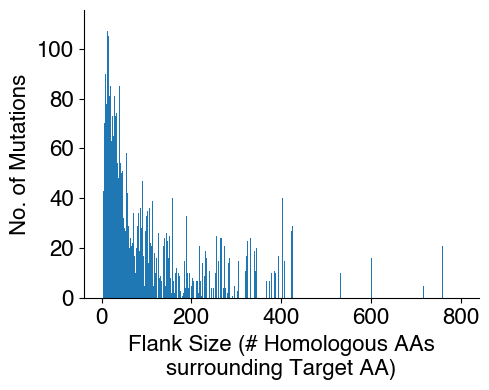

In [ ]:
flank_merge = pd.merge(flank2, MBES_subset_no_dups, on='identifier')
flank_merge[flank_merge['classification_h'].isin(['Missense', 'Nonsense'])]
np.unique(flank_merge['flank_size'], return_counts=True)


fig, ax = plt.subplots(figsize=(5,4))

ax.hist(flank_merge['flank_size'], bins = np.linspace(0,800, 801))

ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=16,)
ax.set_ylabel('No. of Mutations', fontsize=16)
ax.set_xlabel('Flank Size (# Homologous AAs\nsurrounding Target AA)', fontsize=16)
fig.tight_layout()
#fig.savefig('figures/extended_1a.pdf')


## 1b

Barplot showing the number of mutations with an optimal NG PAM present (n = 7,783) versus an optimal NGG PAM present (n = 2,828), reflecting the expanded targeting range afforded by the NG PAM-compatible base editors used in MBESv2.

In [ ]:
MBES = pd.read_csv('MBESv2_CORRECTED.csv')

input_data = pd.read_csv('source-data/msk_BE_pts_over_2_v2.csv')
input_data2 = pd.read_csv('source-data/input_MSK_over_2.csv')

#AACR mutational info available from genie portal: https://genie.synapse.org/Explore/GENIE
#or cBioPortal for a subset: https://www.cbioportal.org/
#File too large for inclusion in repository

In [ ]:
df_mutation = pd.read_csv('/Users/kexindong/Documents/GitHub/Database/PublicDatabase/AACR-GENIE/v13.1/data_mutations_extended.txt', header=0, sep='\t', comment="#", na_values = 'Not Applicable')

# only keep MSK data
df_mutation = df_mutation.iloc[:,[0, 37,2, 5,6,9,10,11,13,16]].reset_index(drop=True)
df_mutation = df_mutation[df_mutation['Center']=='MSK'].reset_index(drop=True)
df_mutation = df_mutation[df_mutation['Variant_Type'] == 'SNP'].reset_index(drop=True)
df_mutation = df_mutation.dropna(subset='HGVSc').reset_index(drop=True)
df_mutation['HGVSc'] = [x.split(':')[0] for x in df_mutation['HGVSc']]
df_mutation = df_mutation.drop_duplicates().reset_index(drop=True)

#and count tumor samples for a given mutation (by HGVSc)
df_mutation_count = df_mutation.groupby([df_mutation.columns.tolist()[x] for x in [0,1,3,4,5,6,7,8]], as_index = False).size()
df_mutation_count_sorted = df_mutation_count.sort_values(by = 'size')
df_mutation_count_sorted.columns =['gene_name_h', 'tx_id_h','start_h','end_h','class_h','type_h','ref_seq_h','alt_seq_h','count']

In [ ]:
mutations_over_2 = df_mutation_count_sorted[df_mutation_count_sorted['count']>2].reset_index(drop=True)

alteration = []
for i, val in mutations_over_2.iterrows():
    ref = val['ref_seq_h']
    alt = val['alt_seq_h']
    alteration.append(f'{ref}>{alt}')

mutations_over_2['alteration'] = alteration

mutations_over_2_BE_amenable = mutations_over_2[mutations_over_2['alteration'].isin(['C>T', 'G>A', 'A>G', 'T>C'])]

In [ ]:
#for full h2m database, please visit: https://human2mouse.com/ (https://human2mouse.com/download)
#File too large for inclusion in repository
h2m = pd.read_csv('/Users/kexindong/Documents/GitHub/Output/h2m_database/database-output-final/df_result_cleaned_v3.csv')

In [ ]:
h2m_subset = h2m[(h2m['gene_name_h'].isin(list(np.unique(mutations_over_2['gene_name_h']))))].reset_index(drop=True)

In [ ]:
identifier = []
for i, val in mutations_over_2.iterrows():
    a = val['gene_name_h']
    b = val['start_h']
    c = val['ref_seq_h']
    d = val['alt_seq_h']
    identifier.append(f'{a}_{b}_{c}_{d}')

mutations_over_2['identifier'] = identifier

identifier2 = []
for i, val in h2m_subset.iterrows():
    a = val['gene_name_h']
    b = val['start_h']
    c = val['ref_seq_h']
    d = val['alt_seq_h']
    identifier2.append(f'{a}_{b}_{c}_{d}')

h2m_subset['identifier'] = identifier2

In [ ]:
h2m_subset_MSK = h2m_subset[h2m_subset['identifier'].isin(identifier)].drop_duplicates(subset='identifier').reset_index(drop=True)
h2m_subset_MSK

,gene_name_h,gene_id_h,tx_id_h,chr_h,exon_num_h,strand_h,match,start_h,end_h,ref_seq_h,...,ID_mouse,Database,ID_db,pe_human,pe_mouse,be_human,be_mouse,expanded,flank_size,identifier
0,ABL1,ENSG00000097007.13,ENST00000318560.5,chr9,11,+,True,133760790,133760790,C,...,AACR-H0005263-M01-V01,AACR,NaN,False,False,False,False,False,64,ABL1_133760790_C_T
1,ABL1,ENSG00000097007.13,ENST00000318560.5,chr9,11,+,True,133760714,133760714,C,...,AACR-H0010708-M01-V01,AACR,NaN,False,False,False,False,False,23,ABL1_133760714_C_T
2,ABL1,ENSG00000097007.13,ENST00000318560.5,chr9,11,+,True,133759967,133759967,C,...,AACR-H0010908-M01-V01,AACR,NaN,False,False,False,False,False,20,ABL1_133759967_C_T
3,ABL1,ENSG00000097007.13,ENST00000318560.5,chr9,11,+,True,133753910,133753910,G,...,AACR-H0010980-M01-V01,AACR,NaN,False,False,False,False,False,175,ABL1_133753910_G_A
4,ABL1,ENSG00000097007.13,ENST00000318560.5,chr9,11,+,True,133738360,133738360,G,...,AACR-H0013487-M01-V01,AACR,NaN,False,False,False,False,False,109,ABL1_133738360_G_A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24876,ZRSR2,ENSG00000169249.8,ENST00000307771.7,chrX,11,+,True,15841258,15841258,C,...,AACR-H0032459-M01-V01,AACR,NaN,False,False,False,False,False,9,ZRSR2_15841258_C_T
24877,ZRSR2,ENSG00000169249.8,ENST00000307771.7,chrX,11,+,True,15841301,15841301,G,...,AACR-H0046678-M01-V01,AACR,NaN,False,False,False,False,False,5,ZRSR2_15841301_G_A
24878,ZRSR2,ENSG00000169249.8,ENST00000307771.7,chrX,11,+,True,15836766,15836766,G,...,AACR-H0012836-M01-V01,AACR,NaN,False,False,False,False,False,1,ZRSR2_15836766_G_A
24879,ZRSR2,ENSG00000169249.8,ENST00000307771.7,chrX,11,+,True,15840928,15840928,G,...,NaN,AACR,NaN,False,False,False,False,False,0,ZRSR2_15840928_G_C


In [ ]:
sub3 = h2m_subset_MSK[h2m_subset_MSK['statement'].isin(['Class 0: This mutation can be originally modeled.',
       'Class 1: This mutation can be alternatively modeled.',
       'Class 2: This mutation can be modeled, but the effect may not be consistent.',
       'Class 4: Mutated sequences are not identical.'])]

alt2 = []
for i, val in sub3.iterrows():
    r = val['ref_seq_m']
    a = val['alt_seq_m']
    alt2.append(f'{r}>{a}')

sub3['alteration'] = alt2
sub4 = sub3[sub3['alteration'].isin(['C>T', 'G>A', 'A>G', 'T>C'])]

sub4['fs_right'] = [int(i[:-2]) for i in sub4['flank_size_right']]
sub4['fs_left'] = [int(i[:-2]) for i in sub4['flank_size_left']]

flank2 = sub4[(sub4['fs_right']>=2) & (sub4['fs_left']>=2)]

In [ ]:
identifier3 = []
for i, val in input_data.iterrows():
    a = val['gene_name_h']
    b = int(val['start_h'])
    c = val['ref_seq_h']
    d = val['alt_seq_h']
    identifier3.append(f'{a}_{b}_{c}_{d}')

input_data['identifier']=identifier3

MBES_subset = MBES[(MBES['legacy']==False) & (MBES['classification']=='targeting guide')]

identifier4 = []
for i, val in MBES_subset.iterrows():
    a = val['gene_name_h']
    b = int(val['start_h'])
    c = val['ref_seq_h']
    d = val['alt_seq_h']
    identifier4.append(f'{a}_{b}_{c}_{d}')

MBES_subset['identifier']=identifier4
MBES_subset_no_dups = MBES_subset[['gene_name_m', 'start_m', 'end_m', 'ref_seq_m', 'alt_seq_m', 'identifier']].drop_duplicates()

assert len(MBES_subset_no_dups) == len(input_data[input_data['identifier'].isin(list(np.unique(identifier4)))])

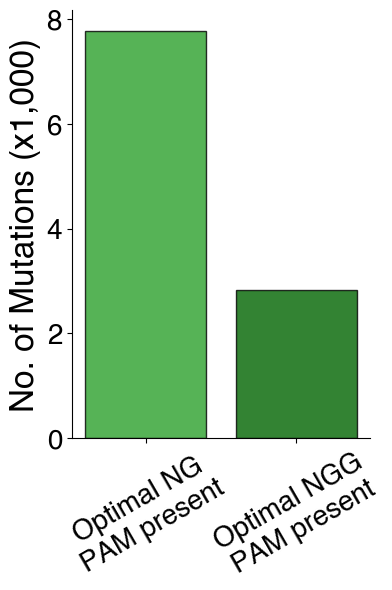

In [ ]:
#increase in coverage of targetable mutations with NGN PAM editors
PAM_NGG = [f"{x}GG" for x in ['A','T','C','G']]
MBES_subset_NGG = MBES_subset[MBES_subset['PAM_NGN'].isin(PAM_NGG)].reset_index(drop=True)
MBES_subset_no_dups_NGG = MBES_subset_NGG[['gene_name_m', 'start_m', 'end_m', 'ref_seq_m', 'alt_seq_m', 'identifier']].drop_duplicates()

heights3 = [len(MBES_subset_no_dups), len(MBES_subset_no_dups_NGG)]

fig, ax = plt.subplots(1,1, figsize=(4,6))

#ax[0].bar([0,1], heights1)
ax.bar([0,1], heights3, edgecolor='black', linewidth=1, color = ['tab:green','darkgreen'], alpha=.8)

ax.set_yticks([0,2e3,4e3,6e3,8e3])
ax.set_yticklabels([0,2,4,6,8], fontsize=24)

ax.set_ylabel('No. of Mutations (x1,000)', fontsize=24)
ax.set_xticks([0,1])
ax.set_xticklabels(['Optimal NG\nPAM present', 'Optimal NGG\nPAM present'], fontsize=20)
ax.tick_params(axis='x', rotation=30)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=20);
fig.tight_layout()
plt.savefig('figures/original_NGG.pdf')

In [ ]:
len(MBES_subset_no_dups_NGG)

2828

In [ ]:
len(MBES_subset_no_dups)

7783

In [ ]:
7783/2828

2.7521216407355023

## 1c

Histogram of the target base location within the protospacer for MBESv2 gRNAs.

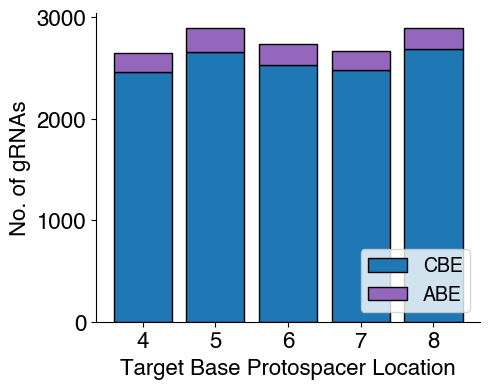

In [6]:
ABE = MBES_targ[MBES_targ['Editor']=='ABE']
CBE = MBES_targ[MBES_targ['Editor']=='CBE']

u, c = np.unique(CBE['Protospacer_Location'], return_counts=True)
u1,c1 = np.unique(ABE['Protospacer_Location'], return_counts=True)

fig, ax = plt.subplots(figsize=(5,4))

ax.bar(u, c, linewidth=1, edgecolor='black', color='tab:blue', label='CBE')
ax.bar(u1, c1, bottom = c, linewidth=1, edgecolor='black', color='tab:purple', label='ABE')
ax.legend(fontsize=14, loc='lower right')
ax.set_xticks([4,5,6,7,8])
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=16,)
ax.set_ylabel('No. of gRNAs', fontsize=16)
ax.set_xlabel('Target Base Protospacer Location', fontsize=16)
fig.tight_layout()
#fig.savefig('figures/extended_1b.pdf')

## 1d

Histogram of the number of gRNAs per mutation.

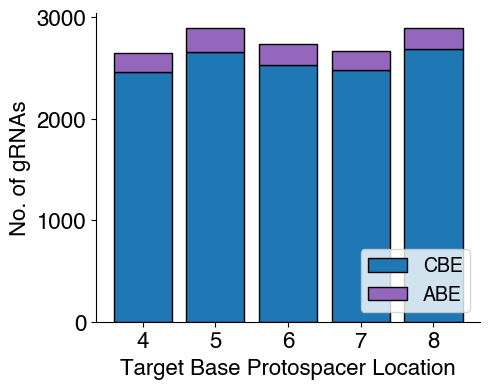

In [ ]:
ABE = MBES_targ[MBES_targ['Editor']=='ABE']
CBE = MBES_targ[MBES_targ['Editor']=='CBE']

u, c = np.unique(CBE['Protospacer_Location'], return_counts=True)
u1,c1 = np.unique(ABE['Protospacer_Location'], return_counts=True)

fig, ax = plt.subplots(figsize=(5,4))

ax.bar(u, c, linewidth=1, edgecolor='black', color='tab:blue', label='CBE')
ax.bar(u1, c1, bottom = c, linewidth=1, edgecolor='black', color='tab:purple', label='ABE')
ax.legend(fontsize=14, loc='lower right')
ax.set_xticks([4,5,6,7,8])
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=16,)
ax.set_ylabel('No. of gRNAs', fontsize=16)
ax.set_xlabel('Target Base Protospacer Location', fontsize=16)
fig.tight_layout()
#fig.savefig('figures/extended_1d.pdf')

## 1e

Histogram of the Rule Set 2 (Azimuth) on-target score for gRNAs included in the library.

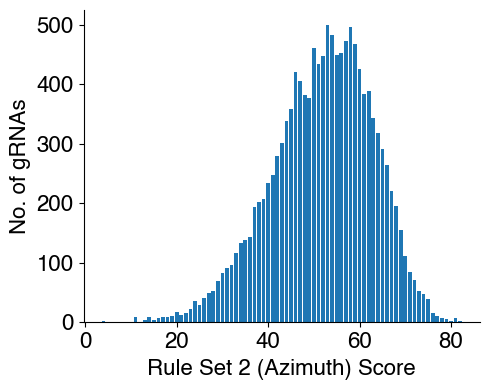

In [ ]:
MBES_non_leg = MBES_targ[MBES_targ['legacy']==False]

u, c = np.unique(MBES_non_leg['OnTarget_Azimuth_Score'], return_counts=True)

fig, ax = plt.subplots(figsize=(5,4))

ax.bar(u, c, linewidth=0)
#ax.set_xticks([4,5,6,7,8])
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=16,)
ax.set_ylabel('No. of gRNAs', fontsize=16)
ax.set_xlabel('Rule Set 2 (Azimuth) Score', fontsize=16)
fig.tight_layout()
#fig.savefig('figures/extended_1d.pdf')

## 1f

Pie chart of the ABE Subpool of MBESv2. NT, non-targeting guide; ST, safe-targeting guide.

## 1g

Pie chart of the CBE Subpool of MBESv2. NT, non-targeting guide; ST, safe-targeting guide.

In [ ]:
#ABE_controls = pd.DataFrame(dict(zip(['NT', 'ST'], [10,26])))
ABE_controls = pd.DataFrame(dict(zip(['u','c'], [['NT', 'ST'],[10, 26]])))
CBE_controls = pd.DataFrame(dict(zip(['u','c'], [['NT', 'ST'],[123, 313]])))

ABE_u, ABE_c = ['Missense', 'Splice/Intron', 'Nonstop'], [980, 53, 1]
CBE_u, CBE_c = ['Missense', 'Splice/Intron', 'Nonsense'], [10373+418, 177+33, 1675+130]

ABE_df = pd.DataFrame(dict(zip(['u', 'c'], [ABE_u,ABE_c])))
CBE_df = pd.DataFrame(dict(zip(['u', 'c'], [CBE_u,CBE_c])))

ABE_final = pd.concat((ABE_df, ABE_controls))
CBE_final = pd.concat((CBE_df, CBE_controls))

print(len(MBES[MBES['Editor']=='ABE']))
print(sum(ABE_final['c']))
print(len(MBES[MBES['Editor']=='CBE']))
print(sum(CBE_final['c']))


1070
1070
13242
13242


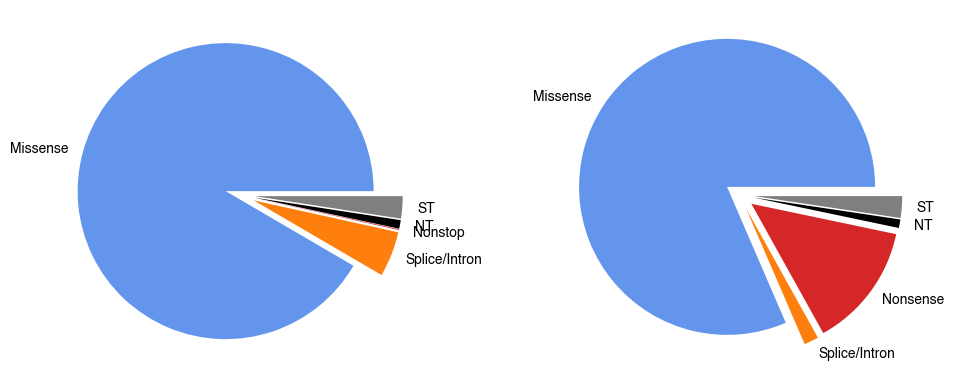

In [ ]:

fig, ax = plt.subplots(1,2,figsize=(10,4))


colors1=['cornflowerblue', 'tab:orange', 'tab:red', 'black', 'tab:grey']
colors2=['cornflowerblue', 'tab:orange', 'tab:red', 'black', 'tab:grey']

ax[0].pie(ABE_final['c'], explode=[.1]*len(ABE_final),labels=ABE_final['u'], colors=colors1)
ax[1].pie(CBE_final['c'], explode=[.1]*len(CBE_final),labels=CBE_final['u'], colors=colors2)

fig.tight_layout()
#fig.savefig('figures/extended_1ef.pdf')